In [124]:
# ==============================
# Import Required Libraries
# ==============================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)

# Save Model
import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [125]:
# ==============================
# Read Dataset
# ==============================

app = pd.read_csv("application_record.csv")
credit = pd.read_csv("credit_record.csv")

print("Application Dataset Shape :", app.shape)
print("Credit Dataset Shape :", credit.shape)

Application Dataset Shape : (438557, 18)
Credit Dataset Shape : (1048575, 3)


In [126]:
# First 5 Rows
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [127]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [128]:
# Dataset Information
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [129]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [130]:
# Column Names
print(app.columns)

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')


In [131]:
print(credit.columns)

Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='object')


In [132]:
# Dataset Dimensions
print("Application Dataset:", app.shape)
print("Credit Dataset:", credit.shape)

Application Dataset: (438557, 18)
Credit Dataset: (1048575, 3)


In [133]:
print("Occupation Type Count")
print(app["OCCUPATION_TYPE"].value_counts())

Occupation Type Count
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


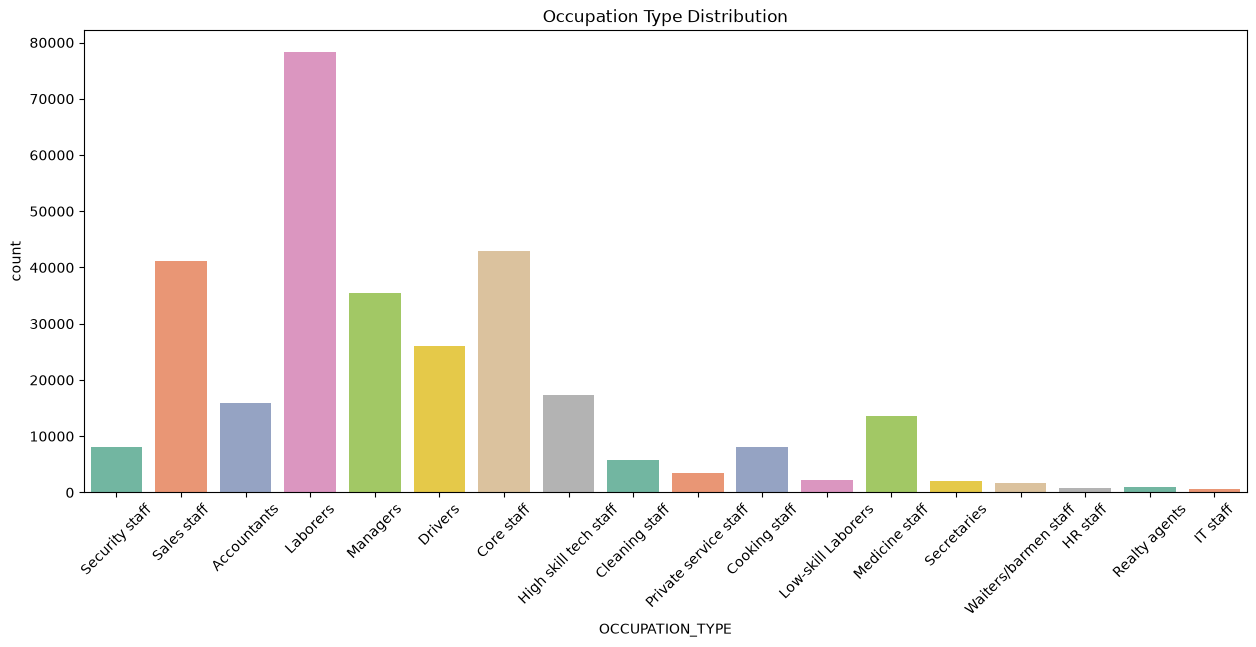

In [134]:
plt.figure(figsize=(15,6))

sns.countplot(
    x="OCCUPATION_TYPE",
    data=app,
    palette="Set2",
    hue="OCCUPATION_TYPE",
    legend=False
)

plt.xticks(rotation=45)
plt.title("Occupation Type Distribution")
plt.show()

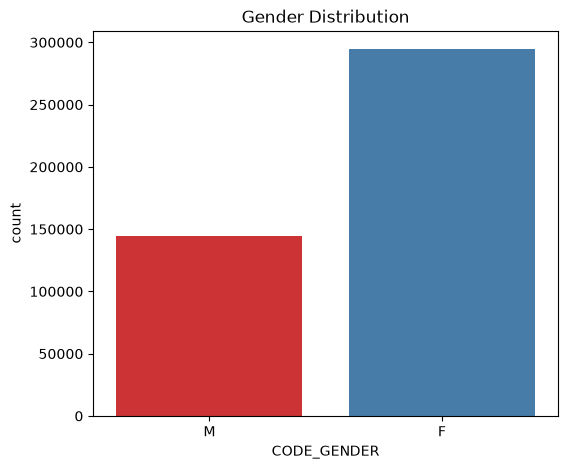

In [135]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="CODE_GENDER",
    data=app,
    palette="Set1",
    hue="CODE_GENDER",
    legend=False
)

plt.title("Gender Distribution")
plt.show()

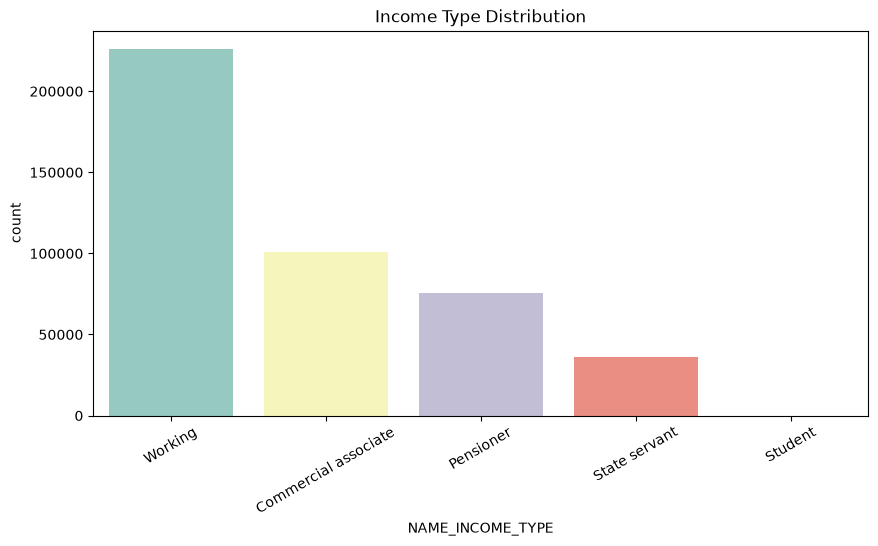

In [136]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="NAME_INCOME_TYPE",
    data=app,
    palette="Set3",
    hue="NAME_INCOME_TYPE",
    legend=False
)

plt.xticks(rotation=30)
plt.title("Income Type Distribution")
plt.show()

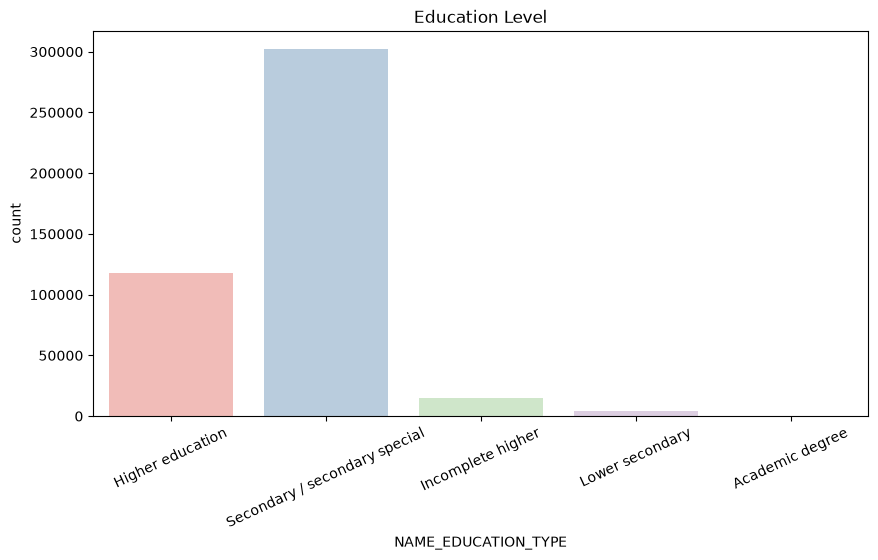

In [137]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="NAME_EDUCATION_TYPE",
    data=app,
    palette="Pastel1",
    hue="NAME_EDUCATION_TYPE",
    legend=False
)

plt.xticks(rotation=25)
plt.title("Education Level")
plt.show()

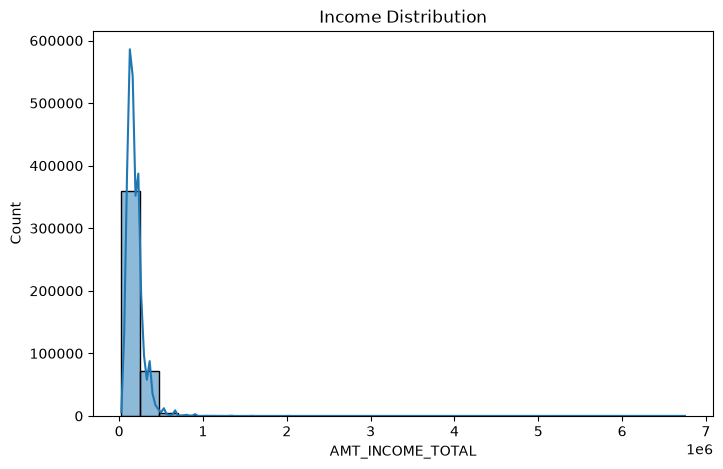

In [138]:
plt.figure(figsize=(8,5))

sns.histplot(
    app["AMT_INCOME_TOTAL"],
    bins=30,
    kde=True
)

plt.title("Income Distribution")
plt.show()

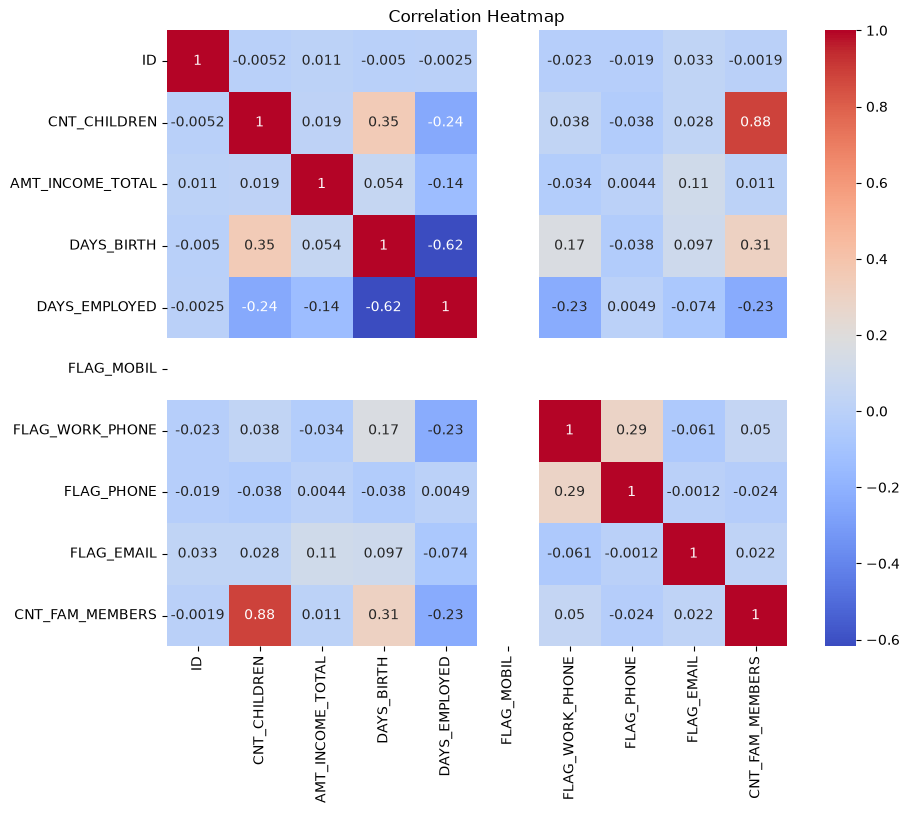

In [139]:
plt.figure(figsize=(10,8))

sns.heatmap(
    app.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [140]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [141]:
credit.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [142]:
print(app.isnull().sum())

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64


In [143]:
print(credit.isnull().sum())

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


In [144]:
print("Application Duplicate Rows :", app.duplicated().sum())
print("Credit Duplicate Rows :", credit.duplicated().sum())

Application Duplicate Rows : 0
Credit Duplicate Rows : 0


In [145]:
# ==========================================
# Remove Duplicate Records
# ==========================================

app.drop_duplicates(
    subset=[
        'CODE_GENDER',
        'FLAG_OWN_CAR',
        'FLAG_OWN_REALTY',
        'CNT_CHILDREN',
        'AMT_INCOME_TOTAL',
        'NAME_INCOME_TYPE',
        'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS',
        'NAME_HOUSING_TYPE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'FLAG_MOBIL',
        'FLAG_WORK_PHONE',
        'FLAG_PHONE',
        'FLAG_EMAIL',
        'OCCUPATION_TYPE',
        'CNT_FAM_MEMBERS'
    ],
    keep='first',
    inplace=True
)

print("Application Dataset Shape :", app.shape)

Application Dataset Shape : (90085, 18)


In [146]:
# ==========================================
# Missing Values
# ==========================================

print("Missing Values Count")
print(app.isnull().sum())

print("\nMissing Value Percentage")
print(app.isnull().mean()*100)

Missing Values Count
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        27477
CNT_FAM_MEMBERS            0
dtype: int64

Missing Value Percentage
ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BIRTH              0.000000
DAYS_EMPLOYED           0.000000
FLAG_MOBIL            

In [147]:
app.drop(columns=["OCCUPATION_TYPE"], inplace=True)

print(app.shape)

(90085, 17)


In [148]:
# ==========================================
# Data Cleaning
# ==========================================

app["DAYS_BIRTH"] = abs(app["DAYS_BIRTH"])
app["DAYS_EMPLOYED"] = abs(app["DAYS_EMPLOYED"])

app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,21474,1134,1,0,0,0,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,19110,3051,1,0,1,1,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,22464,365243,1,0,0,0,1.0
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,16872,769,1,1,1,1,2.0


In [149]:
# ==========================================
# Open Month
# ==========================================

open_month = credit.groupby("ID")["MONTHS_BALANCE"].min().reset_index()
open_month.columns = ["ID","OPEN_MONTH"]

open_month.head()

,ID,OPEN_MONTH
0,5001711,-3
1,5001712,-18
2,5001713,-21
3,5001714,-14
4,5001715,-59


In [150]:
# ==========================================
# End Month
# ==========================================

end_month = credit.groupby("ID")["MONTHS_BALANCE"].max().reset_index()
end_month.columns = ["ID","END_MONTH"]

end_month.head()

,ID,END_MONTH
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [151]:
# ==========================================
# Merge Open and End Month
# ==========================================

activity = pd.merge(open_month,end_month,on="ID")

activity["WINDOW"] = (
    activity["END_MONTH"]
    -
    activity["OPEN_MONTH"]
    +
    1
)

activity.head()

,ID,OPEN_MONTH,END_MONTH,WINDOW
0,5001711,-3,0,4
1,5001712,-18,0,19
2,5001713,-21,0,22
3,5001714,-14,0,15
4,5001715,-59,0,60


In [152]:
credit_copy = credit.copy()

credit_copy["IS_OVERDUE"] = (
    credit_copy["STATUS"]
    .isin(["1","2","3","4","5"])
    .astype(int)
)

overdue = (
    credit_copy
    .groupby("ID")["IS_OVERDUE"]
    .sum()
    .reset_index()
)

overdue.head()

,ID,IS_OVERDUE
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [153]:
credit_clean = pd.merge(
    activity,
    overdue,
    on="ID"
)

credit_clean.head()

,ID,OPEN_MONTH,END_MONTH,WINDOW,IS_OVERDUE
0,5001711,-3,0,4,0
1,5001712,-18,0,19,0
2,5001713,-21,0,22,0
3,5001714,-14,0,15,0
4,5001715,-59,0,60,0


In [154]:
# ==========================================
# Convert STATUS to Binary
# ==========================================

def status_binary(status):

    if status in ["C","X","0"]:
        return 1

    else:
        return 0


credit["STATUS_BIN"] = credit["STATUS"].apply(status_binary)

credit.head()

,ID,MONTHS_BALANCE,STATUS,STATUS_BIN
0,5001711,0,X,1
1,5001711,-1,0,1
2,5001711,-2,0,1
3,5001711,-3,0,1
4,5001712,0,C,1


In [155]:
print(credit["STATUS_BIN"].value_counts())

STATUS_BIN
1    1034381
0      14194
Name: count, dtype: int64


In [156]:
# ==========================================
# Merge Datasets
# ==========================================

final_df = pd.merge(
    app,
    credit,
    on="ID",
    how="inner"
)

print(final_df.shape)

final_df.head()

(219173, 20)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,STATUS_BIN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,0,C,1
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-1,C,1
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-2,C,1
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-3,C,1
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-4,C,1


In [157]:
final_df.drop(
    columns=[
        "STATUS"
    ],
    inplace=True
)

final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS_BIN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,0,1
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-1,1
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-2,1
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-3,1
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-4,1


In [158]:
# ==========================================
# Label Encoding
# ==========================================

encoder = LabelEncoder()

categorical_columns = [

    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"

]

for col in categorical_columns:

    final_df[col] = encoder.fit_transform(
        final_df[col]
    )

print("Encoding Completed")

Encoding Completed


In [159]:
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS_BIN
0,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,0,1
1,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,-1,1
2,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,-2,1
3,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,-3,1
4,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,-4,1


In [160]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219173 entries, 0 to 219172
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   219173 non-null  int64  
 1   CODE_GENDER          219173 non-null  int64  
 2   FLAG_OWN_CAR         219173 non-null  int64  
 3   FLAG_OWN_REALTY      219173 non-null  int64  
 4   CNT_CHILDREN         219173 non-null  int64  
 5   AMT_INCOME_TOTAL     219173 non-null  float64
 6   NAME_INCOME_TYPE     219173 non-null  int64  
 7   NAME_EDUCATION_TYPE  219173 non-null  int64  
 8   NAME_FAMILY_STATUS   219173 non-null  int64  
 9   NAME_HOUSING_TYPE    219173 non-null  int64  
 10  DAYS_BIRTH           219173 non-null  int64  
 11  DAYS_EMPLOYED        219173 non-null  int64  
 12  FLAG_MOBIL           219173 non-null  int64  
 13  FLAG_WORK_PHONE      219173 non-null  int64  
 14  FLAG_PHONE           219173 non-null  int64  
 15  FLAG_EMAIL       

In [161]:
print("Final Dataset Shape :", final_df.shape)

Final Dataset Shape : (219173, 19)


In [162]:
# ==========================================
# Feature Selection
# ==========================================

# Features
X = final_df.drop(columns=["ID", "STATUS_BIN", "MONTHS_BALANCE"])

# Target Variable
y = final_df["STATUS_BIN"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (219173, 16)
Target Shape : (219173,)


In [163]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (175338, 16)
Testing Features : (43835, 16)
Training Labels : (175338,)
Testing Labels : (43835,)


In [164]:
# ==========================================
# Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

print("Training Logistic Regression...")

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nAccuracy :",
      accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")

print(classification_report(y_test, lr_pred))

Training Logistic Regression...



Accuracy : 0.9828675715752253

Confusion Matrix
[[    0   751]
 [    0 43084]]

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       751
           1       0.98      1.00      0.99     43084

    accuracy                           0.98     43835
   macro avg       0.49      0.50      0.50     43835
weighted avg       0.97      0.98      0.97     43835



In [165]:
# ==========================================
# Random Forest
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=160,
    random_state=42,
    n_jobs=-1

)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nAccuracy :",
      accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")

print(classification_report(y_test, rf_pred))

Training Random Forest...

Accuracy : 0.9832325767081099

Confusion Matrix
[[  111   640]
 [   95 42989]]

Classification Report
              precision    recall  f1-score   support

           0       0.54      0.15      0.23       751
           1       0.99      1.00      0.99     43084

    accuracy                           0.98     43835
   macro avg       0.76      0.57      0.61     43835
weighted avg       0.98      0.98      0.98     43835



In [166]:
# ==========================================
# Decision Tree
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

print("Training Decision Tree...")

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\nAccuracy :",
      accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")

print(classification_report(y_test, dt_pred))

Training Decision Tree...

Accuracy : 0.9831185126040834

Confusion Matrix
[[  115   636]
 [  104 42980]]

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.15      0.24       751
           1       0.99      1.00      0.99     43084

    accuracy                           0.98     43835
   macro avg       0.76      0.58      0.61     43835
weighted avg       0.98      0.98      0.98     43835



In [167]:
# ==========================================
# Gradient Boosting
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

print("Training Gradient Boosting...")

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("\nAccuracy :",
      accuracy_score(y_test, gb_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report")

print(classification_report(y_test, gb_pred))

Training Gradient Boosting...

Accuracy : 0.9829360100376412

Confusion Matrix
[[    6   745]
 [    3 43081]]

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       751
           1       0.98      1.00      0.99     43084

    accuracy                           0.98     43835
   macro avg       0.82      0.50      0.50     43835
weighted avg       0.98      0.98      0.97     43835



In [168]:
print("="*50)
print("All Machine Learning Models Trained Successfully")
print("="*50)

print("1. Logistic Regression")
print("2. Random Forest")
print("3. Decision Tree")
print("4. Gradient Boosting")

All Machine Learning Models Trained Successfully
1. Logistic Regression
2. Random Forest
3. Decision Tree
4. Gradient Boosting


In [169]:
# ==========================================
# Compare Model Accuracy
# ==========================================

from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
dt_acc = accuracy_score(y_test, dt_pred)
gb_acc = accuracy_score(y_test, gb_pred)

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "Gradient Boosting"
    ],

    "Accuracy":[
        lr_acc,
        rf_acc,
        dt_acc,
        gb_acc
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.982868
1,Random Forest,0.983233
2,Decision Tree,0.983119
3,Gradient Boosting,0.982936


In [170]:
print("="*50)
print("Model Accuracy")
print("="*50)

print(f"Logistic Regression : {lr_acc:.4f}")
print(f"Random Forest       : {rf_acc:.4f}")
print(f"Decision Tree       : {dt_acc:.4f}")
print(f"Gradient Boosting   : {gb_acc:.4f}")

Model Accuracy
Logistic Regression : 0.9829
Random Forest       : 0.9832
Decision Tree       : 0.9831
Gradient Boosting   : 0.9829


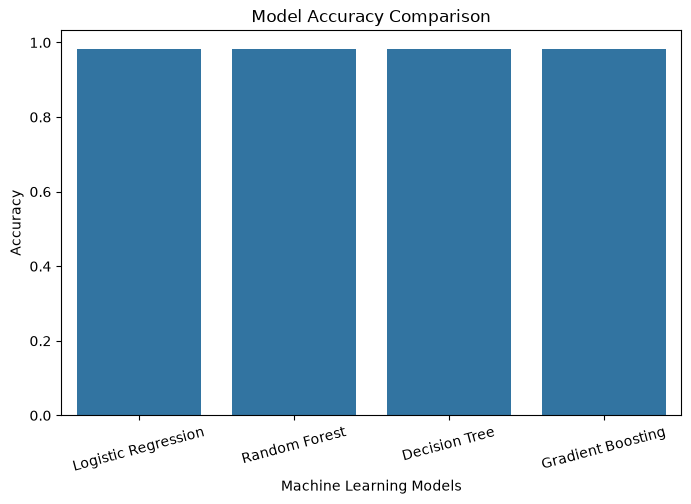

In [171]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

In [172]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, lr_pred)
rf_f1 = f1_score(y_test, rf_pred)
dt_f1 = f1_score(y_test, dt_pred)
gb_f1 = f1_score(y_test, gb_pred)

f1_df = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "Gradient Boosting"
    ],

    "F1 Score":[
        lr_f1,
        rf_f1,
        dt_f1,
        gb_f1
    ]

})

f1_df

,Model,F1 Score
0,Logistic Regression,0.991360
1,Random Forest,0.991524
2,Decision Tree,0.991465
3,Gradient Boosting,0.991393


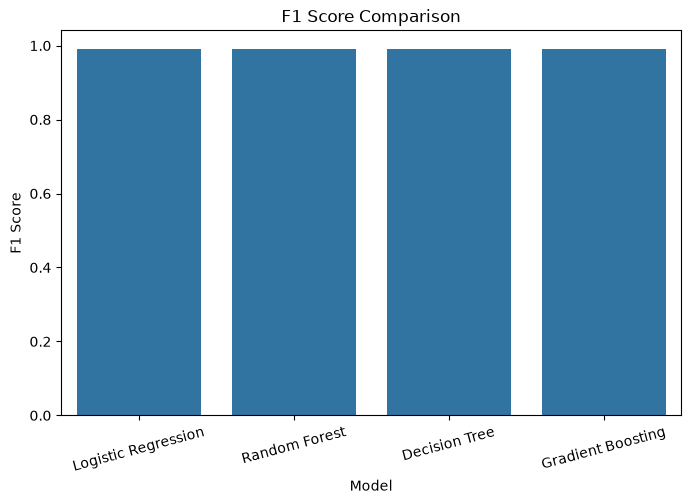

In [173]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="F1 Score",
    data=f1_df
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=15)

plt.show()

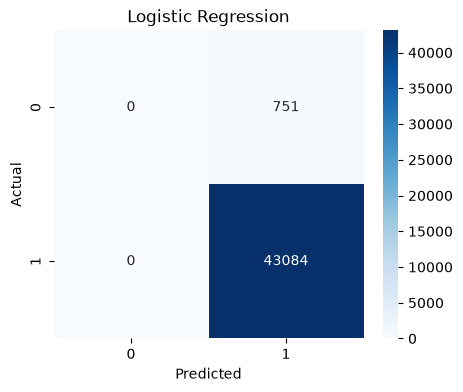

In [174]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

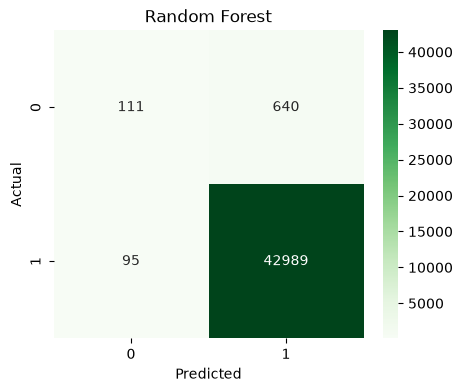

In [175]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

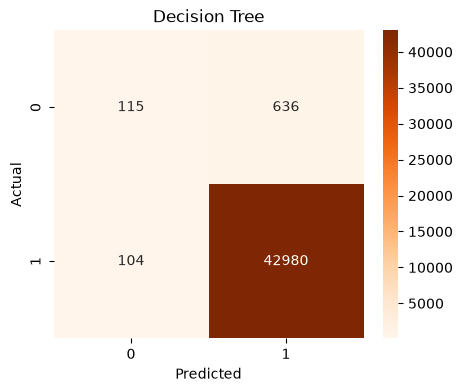

In [176]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

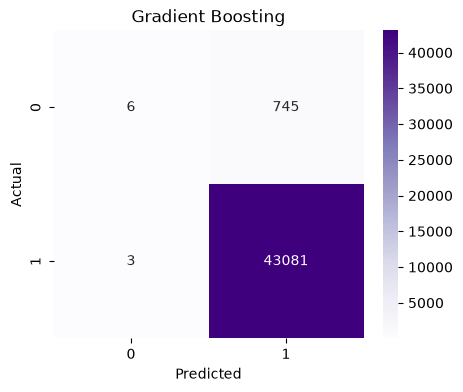

In [177]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, gb_pred),
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [178]:
accuracy_scores = {

    "Logistic Regression": lr_acc,
    "Random Forest": rf_acc,
    "Decision Tree": dt_acc,
    "Gradient Boosting": gb_acc

}

best_model_name = max(
    accuracy_scores,
    key=accuracy_scores.get
)

print("Best Model :", best_model_name)

Best Model : Random Forest


In [179]:
if best_model_name == "Logistic Regression":

    best_model = lr_model

elif best_model_name == "Random Forest":

    best_model = rf_model

elif best_model_name == "Decision Tree":

    best_model = dt_model

else:

    best_model = gb_model

In [180]:
import joblib

joblib.dump(
    best_model,
    "credit_card_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [181]:


#files.download("credit_card_model.pkl")

In [182]:
import os

print(os.listdir())

['app.py', 'application_record.csv', 'car_encoder.pkl', 'credit_card_model.pkl', 'Credit_Card_Prediction.ipynb', 'credit_record.csv', 'education_encoder.pkl', 'family_encoder.pkl', 'gender_encoder.pkl', 'housing_encoder.pkl', 'income_encoder.pkl', 'Project Documentation', 'README.md', 'realty_encoder.pkl', 'requirements.txt', 'screenshots', 'static', 'templates']


In [183]:
print(X.columns.tolist())

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS']


In [184]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Gender
cg = LabelEncoder()
cg.fit(app["CODE_GENDER"])
joblib.dump(cg, "gender_encoder.pkl")

# Car
oc = LabelEncoder()
oc.fit(app["FLAG_OWN_CAR"])
joblib.dump(oc, "car_encoder.pkl")

# Realty
own_r = LabelEncoder()
own_r.fit(app["FLAG_OWN_REALTY"])
joblib.dump(own_r, "realty_encoder.pkl")

# Income
it = LabelEncoder()
it.fit(app["NAME_INCOME_TYPE"])
joblib.dump(it, "income_encoder.pkl")

# Education
et = LabelEncoder()
et.fit(app["NAME_EDUCATION_TYPE"])
joblib.dump(et, "education_encoder.pkl")

# Family
fs = LabelEncoder()
fs.fit(app["NAME_FAMILY_STATUS"])
joblib.dump(fs, "family_encoder.pkl")

# Housing
ht = LabelEncoder()
ht.fit(app["NAME_HOUSING_TYPE"])
joblib.dump(ht, "housing_encoder.pkl")

['housing_encoder.pkl']

In [185]:
print(cg.classes_)
print(oc.classes_)
print(own_r.classes_)
print(it.classes_)
print(et.classes_)
print(fs.classes_)
print(ht.classes_)

['F' 'M']
['N' 'Y']
['N' 'Y']
['Commercial associate' 'Pensioner' 'State servant' 'Student' 'Working']
['Academic degree' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Secondary / secondary special']
['Civil marriage' 'Married' 'Separated' 'Single / not married' 'Widow']
['Co-op apartment' 'House / apartment' 'Municipal apartment'
 'Office apartment' 'Rented apartment' 'With parents']


In [186]:
print(app["CODE_GENDER"].head())

0     M
2     M
3     F
7     F
10    M
Name: CODE_GENDER, dtype: object


In [187]:


#file.download("gender_encoder.pkl")
#files.download("car_encoder.pkl")
#files.download("realty_encoder.pkl")
#files.download("income_encoder.pkl")
#files.download("education_encoder.pkl")
#files.download("family_encoder.pkl")
#files.download("housing_encoder.pkl")

In [188]:
import joblib

gender_encoder = joblib.load("gender_encoder.pkl")
print(gender_encoder.classes_)

['F' 'M']


In [189]:
print(X.head())

   CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  \
0            1             1                1             0          427500.0   
1            1             1                1             0          427500.0   
2            1             1                1             0          427500.0   
3            1             1                1             0          427500.0   
4            1             1                1             0          427500.0   

   NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  NAME_FAMILY_STATUS  \
0                 4                    1                   0   
1                 4                    1                   0   
2                 4                    1                   0   
3                 4                    1                   0   
4                 4                    1                   0   

   NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE  \
0                  4       12005           4542 

In [190]:
pred = best_model.predict(X_test)

print(np.unique(pred, return_counts=True))

(array([0, 1]), array([  206, 43629]))


In [191]:
%who

DecisionTreeClassifier	 GradientBoostingClassifier	 LabelEncoder	 LogisticRegression	 RandomForestClassifier	 X	 X_test	 X_train	 accuracy_score	 
accuracy_scores	 activity	 app	 best_model	 best_model_name	 categorical_columns	 cg	 classification_report	 col	 
comparison	 confusion_matrix	 credit	 credit_clean	 credit_copy	 dt_acc	 dt_f1	 dt_model	 dt_pred	 
encoder	 end_month	 et	 f1_df	 f1_score	 final_df	 fs	 gb_acc	 gb_f1	 
gb_model	 gb_pred	 gender_encoder	 ht	 it	 joblib	 lr_acc	 lr_f1	 lr_model	 
lr_pred	 np	 oc	 open_month	 os	 overdue	 own_r	 pd	 plt	 
pred	 rf_acc	 rf_f1	 rf_model	 rf_pred	 sns	 status_binary	 train_test_split	 warnings	 
y	 y_test	 y_train	 
